# **Projeto de Graduação em Computação II [2026-Q1]**

Universidade Federal do ABC

Orientador Carlos da Silva dos Santos

### **EQUIPE**

---

Caio Cardoso Dos Santos - RA: 11202021632

Victor Ravazio de Lima - RA: 11201920941

### **IMPLEMENTAÇÃO**
---

In [1]:
# modulo para importar dataset a partir de um link
!pip install gdown

In [2]:
!pip install emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 38.4 MB/s eta 0:00:00


In [3]:
#Bibliotecas
import pandas as pd
import numpy as np
import json
from datetime import datetime
from google.colab import files
import gdown
import matplotlib.pyplot as plt


In [4]:
# baixando dataset para o collab
import gdown

file_id = "11c6eKtu2d1kfz8D4nkg2-Yk_TPsA-qOV"
url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(url, "cloroquina.json", quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=11c6eKtu2d1kfz8D4nkg2-Yk_TPsA-qOV
From (redirected): https://drive.google.com/uc?id=11c6eKtu2d1kfz8D4nkg2-Yk_TPsA-qOV&confirm=t&uuid=e8e9b18b-50be-4640-855d-e717f3ae897a
To: /content/cloroquina.json
100%|██████████| 1.94G/1.94G [00:47<00:00, 40.5MB/s]


'cloroquina.json'

In [5]:
#obtendo o caminho do dataset
file_path = "cloroquina.json"


In [6]:
#importando e manipulando o dataset em json Lines (cada linha deste "json" é um "json")

data = [] #lista de jsons - basicamente um dicionario
with open(file_path, "r", encoding="utf-8") as f:
    for line in f:
        data.append(json.loads(line)) #converte o Json em dicionario e adiciona a lista "data"

In [7]:
#extraindo texto completo
def extract_full_text(tweet_obj):
    # Caso truncado
    if tweet_obj.get("truncated"):
        # Se existe versão completa
        if "extended_tweet" in tweet_obj and "full_text" in tweet_obj["extended_tweet"]:
            return tweet_obj["extended_tweet"]["full_text"]
        else:
            # se for truncado e não existir o "full_text", retorna none
            return None
    else:
        return tweet_obj.get("text", "")

In [8]:
def has_image(tweet_obj):
    # checa o próprio tweet
    if "extended_entities" in tweet_obj:
        media = tweet_obj["extended_entities"].get("media", [])
        if any(m.get("type") == "photo" for m in media):
            return True

    #Resolvendo o "problema" - extended entities pode estar em "extended_tweet" e não no tweet base
    if "extended_tweet" in tweet_obj:
        if "extended_entities" in tweet_obj["extended_tweet"]:
            media = tweet_obj["extended_tweet"]["extended_entities"].get("media", [])
            if any(m.get("type") == "photo" for m in media):
                return True

    # checa quote (se existir)
    if tweet_obj.get("is_quote_status") and "quoted_status" in tweet_obj:
        quoted = tweet_obj["quoted_status"]
        if "extended_entities" in quoted:
            media = quoted["extended_entities"].get("media", [])
            if any(m.get("type") == "photo" for m in media):
                return True

    return False

In [9]:
#Construindo lista estruturada
processed = [] #lista de dicionarios (cada tweet é um dicionario - no fim é facil converter dicionario num df)

for tweet in data: #data é uma lista de dicionarios e tweet itera dicionario em dicionario em data

    # Identificando se é retweet
    if "retweeted_status" in tweet:
        base_tweet = tweet["retweeted_status"] #retweeted_status é um subdicionario dentro do dicionario tweets - contem as infos do retweet como texto, autor e etc
        is_retweet = True

        original_tweet_date = base_tweet.get("created_at")
        retweeter_id = tweet.get("user", {}).get("id_str")
        retweet_date = tweet.get("created_at")

    #Caso contrario, é um tweet original
    else:
        base_tweet = tweet
        is_retweet = False

        original_tweet_date = tweet.get("created_at")
        retweeter_id = None
        retweet_date = None

    #verificando se existe imagem (caso sim, desconsiderar o tweet)
    if has_image(base_tweet):
      continue

    # Tratando quotes (respostas)
    is_quote = base_tweet.get("is_quote_status", False) #verificando se é um quote

    if is_quote and "quoted_status" in base_tweet: #se for quote e o campo quote_status (dicionario de elementos, igual retweet status) não for null
        quoted_tweet = base_tweet["quoted_status"] #quoted_status é um subdicionario dentro do dicionario tweets - contem as infos do quote como texto, autor e etc

        quoted_text = extract_full_text(quoted_tweet)
        quoted_tweet_id = quoted_tweet.get("id_str")
        quoted_user_id = quoted_tweet.get("user", {}).get("id_str")
    else:
        quoted_text = None
        quoted_tweet_id = None
        quoted_user_id = None


    #Tratando reply
    is_reply = base_tweet.get("in_reply_to_status_id", False) is not None

    reply_to_tweet_id = base_tweet.get("in_reply_to_status_id_str")
    reply_to_user_id = base_tweet.get("in_reply_to_user_id_str")
    reply_to_screen_name = base_tweet.get("in_reply_to_screen_name")

    #Produzindo o dicionario do tweet e adicionando na lista
    text = extract_full_text(base_tweet)

    # Se text retorna null, descartar
    if text is None:
      continue

    processed.append({
        "tweet_id": base_tweet.get("id_str"),
        "user_id_original": base_tweet.get("user", {}).get("id_str"),
        "text": text,
        "created_at_original": original_tweet_date,

        "retweet_count": base_tweet.get("retweet_count", 0),
        "like_count": base_tweet.get("favorite_count", 0),

        # retweet info
        "is_retweet": is_retweet,
        "retweeter_user_id": retweeter_id,
        "retweet_created_at": retweet_date,

        # quote info
        "is_quote": is_quote,
        "quoted_tweet_id": quoted_tweet_id,
        "quoted_user_id": quoted_user_id,
        "quoted_text": quoted_text,

        # --- REPLY ---
        "is_reply": is_reply,
        "reply_to_tweet_id": reply_to_tweet_id,
        "reply_to_user_id": reply_to_user_id,
        "reply_to_screen_name": reply_to_screen_name
    })

In [10]:
#Criando DataFrame

df = pd.DataFrame(processed)

df
#print(df.shape)

,tweet_id,user_id_original,text,created_at_original,retweet_count,like_count,is_retweet,retweeter_user_id,retweet_created_at,is_quote,quoted_tweet_id,quoted_user_id,quoted_text,is_reply,reply_to_tweet_id,reply_to_user_id,reply_to_screen_name
0,1263053750681382912,74756085,Sem distorções. JB brinca: tubaína ou cloroqui...,Wed May 20 10:27:35 +0000 2020,2464,11709,True,1163629366875688961,Wed May 20 17:48:15 +0000 2020,False,None,None,None,False,None,None,None
1,1263164652806078466,64559578,Está se tornando uma irresponsabilidade a manu...,Wed May 20 17:48:16 +0000 2020,0,0,False,None,None,False,None,None,None,False,None,None,None
2,1263131993895841793,1087259768,Agora é oficial!!!\nVamos de novo: Melhor ter ...,Wed May 20 15:38:29 +0000 2020,934,2934,True,1254218123995201536,Wed May 20 17:48:16 +0000 2020,True,1263130208967766024,128372940,O @minsaude divulga orientações para tratament...,False,None,None,None
3,1263161628620701696,1262972424880041985,O @minsaude publicou nesta manhã o novo protoc...,Wed May 20 17:36:15 +0000 2020,22,61,True,26166110,Wed May 20 17:48:16 +0000 2020,False,None,None,None,False,None,None,None
4,1263154938672267267,1138847289978626049,O UOL fez uma matéria sobre o protocolo para c...,Wed May 20 17:09:40 +0000 2020,276,1196,True,1256311897852465152,Wed May 20 17:48:17 +0000 2020,False,None,None,None,False,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
278057,1263565991793090561,1251891753973690369,Acho bom e vc ficar quieto. Já já pegam seus p...,Thu May 21 20:23:03 +0000 2020,0,0,False,None,None,True,1263453648778153985,34996429,Apresentei um projeto de decreto legislativo p...,False,None,None,None
278058,1263512467440877568,204136120,Bolsonaro. Quis. Alterar. Bula. De. Remédio.,Thu May 21 16:50:21 +0000 2020,3921,17324,True,2277741265,Thu May 21 20:23:03 +0000 2020,True,1263437930997207041,14594698,"Bolsonaro quis alterar bula da cloroquina, diz...",False,None,None,None
278059,1263565993818894336,1208380137798017026,O MP tá dormindo ao invés de fazer algo para c...,Thu May 21 20:23:03 +0000 2020,0,0,False,None,None,True,1263558418159280130,1158389772920020993,O Brasil ganhou mais uma esperança no tratamen...,False,None,None,None
278060,1263106062766321664,1909935600,Qual é a cloroquina da sua profissão?,Wed May 20 13:55:27 +0000 2020,316,6946,False,None,None,False,None,None,None,False,None,None,None


In [11]:
# Buscando textos originais dos replys - O texto original (que esta sendo respondido) não está no tweet que esta respondendo: ideia buscar neste dataset pelo id neste dataset
# garantindo ids em strings
df["tweet_id"] = df["tweet_id"].astype(str)
df["reply_to_tweet_id"] = df["reply_to_tweet_id"].astype(str)

# criar dicionário id -> texto
id_to_text = dict(zip(df["tweet_id"], df["text"])) # Organizando o dataset num dicionario: Chave: tweet id, conteudo: texto - isso facilita a busca (ex: ao fornecer a chave X, retorna seu texto Y)

# Criando reply text: Basicamente varre cada reply_tweet_id do df, e se não for none, aplica no dicionario, ou seja, busca no dicionario aquele tweet id do reply como chave - se encontrar, retorna o conteudo, se não, none
df["reply_text"] = df["reply_to_tweet_id"].map(id_to_text)

In [12]:
#Removendo URLs
import re
import emoji

def clean_text(text):
    if not isinstance(text, str):
        return ""

    text = emoji.replace_emoji(text, replace='')
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"RT\s+", "", text)
    text = re.sub(r"\n", " ", text)
    return text.strip()

df["text"] = df["text"].apply(clean_text)
df["quoted_text"] = df["quoted_text"].apply(clean_text)
df["reply_text"] = df["reply_text"].apply(clean_text)

In [13]:
#removendo textos vazios
df = df[df["text"].notnull()]
df = df[df["text"].str.strip() != ""]
print(df.shape)

(278061, 18)


In [14]:
#replys "usáveis" - Antes de remover duplicatas
replys = df.loc[(df["is_reply"] == True) & (df["reply_text"].str.strip() != "")]

In [ ]:
replys

,tweet_id,user_id_original,text,created_at_original,retweet_count,like_count,is_retweet,retweeter_user_id,retweet_created_at,is_quote,quoted_tweet_id,quoted_user_id,quoted_text,is_reply,reply_to_tweet_id,reply_to_user_id,reply_to_screen_name,reply_text
4,1250828255806009345,1039608133587554311,"Demorou, não deveria ne ter sido nomeado mande...",Thu Apr 16 16:47:50 +0000 2020,0,0,False,None,None,False,None,None,,True,1250553117378088961,1523748277,conexaopolitica,"“O dia que ele [Mandetta] sair, eu saio junto ..."
13,1250828263976558593,170400715,"Como uma cobra ratoeira, está o senhor senador...",Thu Apr 16 16:47:52 +0000 2020,0,0,False,None,None,False,None,None,,True,1250796092092006401,73745956,alvarodias_,A maioria esmagadora dos brasileiros é contrár...
18,1250821578318897156,35219319,#ForaMandettaTraira Eu não fui entrevistada!...,Thu Apr 16 16:21:18 +0000 2020,12,23,True,3127892382,Thu Apr 16 16:47:55 +0000 2020,False,None,None,,True,1250796092092006401,73745956,alvarodias_,A maioria esmagadora dos brasileiros é contrár...
36,1250828326454923267,1095129896630841345,Mandetta é um TRAIDOR!!!! #ForaMandettaUrgente,Thu Apr 16 16:48:06 +0000 2020,0,0,False,None,None,False,None,None,,True,1250782520930598912,33520195,Rconstantino,Mandetta e sua política de isolamento estão lo...
130,1250828470004957186,1244304665317179398,"Mandetta, ficou deslumbrado ao microfone e o t...",Thu Apr 16 16:48:41 +0000 2020,0,0,False,None,None,False,None,None,,True,1250737690879893505,2880932962,o_antagonista,Demissão de Mandetta é rejeitada por 76% dos b...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
263419,1251183729441214464,30752253,"Cadê a máscara e distanciamento, Mandetta ? Ah...",Fri Apr 17 16:20:21 +0000 2020,0,0,False,None,None,False,None,None,,True,1251147808209420290,204368952,laurojardim,Mandetta deixa ministério cantando.
263427,1251183734587633665,917045970931798016,Como sou uma senhora fina não vou escrever o q...,Fri Apr 17 16:20:22 +0000 2020,0,0,False,None,None,False,None,None,,True,1250907090698280963,40095953,SenadoFederal,Senadores se manifestam sobre demissão de Mand...
263430,1250952649056403457,1171843460967665669,Apesar dos elogios por parte da mídia e da opi...,Fri Apr 17 01:02:07 +0000 2020,7,14,True,39990331,Fri Apr 17 16:20:23 +0000 2020,True,1243930849118007298,1171843460967665669,#MaisLidaDaSemana | A mudança de postura do mi...,True,1250950799980724224,1171843460967665669,RevistaBadaro,Rumores da saída de Luiz Henrique Mandetta for...
263501,1251193985634353154,1230272598480760834,"O ex Ministro da Saúde, Luiz Henrique Mandett...",Fri Apr 17 17:01:06 +0000 2020,0,0,False,None,None,False,None,None,,True,1251175228992114689,106175018,JovemPanNews,"O ex-ministro da saúde, Luiz Henrique Mandetta..."


In [15]:
#quotes - Antes de remover duplicatas

quotes = df.loc[(df["is_quote"] == True) & (df["quoted_text"].str.strip() != "")]
quotes

,tweet_id,user_id_original,text,created_at_original,retweet_count,like_count,is_retweet,retweeter_user_id,retweet_created_at,is_quote,quoted_tweet_id,quoted_user_id,quoted_text,is_reply,reply_to_tweet_id,reply_to_user_id,reply_to_screen_name,reply_text
2,1263131993895841793,1087259768,Agora é oficial!!! Vamos de novo: Melhor ter u...,Wed May 20 15:38:29 +0000 2020,934,2934,True,1254218123995201536,Wed May 20 17:48:16 +0000 2020,True,1263130208967766024,128372940,O divulga orientações para tratamento da Covi...,False,None,None,None,
9,1263164662075527170,30931613,"""tem um conhecido meu que é adEvogado e disse ...",Wed May 20 17:48:18 +0000 2020,0,0,False,None,None,True,1263106062766321664,1909935600,Qual é a cloroquina da sua profissão?,False,None,None,None,
21,1263149343026155520,1143196141049323520,Precisamos superar o debate político sobre a c...,Wed May 20 16:47:26 +0000 2020,187,971,True,4421490737,Wed May 20 17:48:21 +0000 2020,True,1263130475167657984,128372940,"- Ainda não existe comprovação científica, mas...",False,None,None,None,
38,1263152814299250688,26991179,“Pior do que ser derrotado é a vergonha de não...,Wed May 20 17:01:13 +0000 2020,1,1,True,1243009385896517632,Wed May 20 17:48:25 +0000 2020,True,1263130475167657984,128372940,"- Ainda não existe comprovação científica, mas...",False,None,None,None,
47,1263164699962638337,1261367834560602117,"""é do levante, tá com Maduro!""",Wed May 20 17:48:27 +0000 2020,0,0,False,None,None,True,1263159080870445057,790680,Cloroquina 'une' Bolsonaro e Maduro em meio à ...,False,None,128372940,jairbolsonaro,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
278053,1263547570200154112,82503870,"Com a palavra, o médico da família :",Thu May 21 19:09:50 +0000 2020,12,63,True,1148785978104004608,Thu May 21 20:23:02 +0000 2020,True,1263442288849682433,60184090,Eu estou preso no paradoxo da cloroquina! O Mi...,False,None,None,None,
278055,1263565990656426001,162110014,Quero ver quem me diz agora que isso não é lob...,Thu May 21 20:23:02 +0000 2020,0,0,False,None,None,True,1263498332590297090,70799317,"Militares já produziram 1,2 milhão de comprimi...",False,None,None,None,
278057,1263565991793090561,1251891753973690369,Acho bom e vc ficar quieto. Já já pegam seus p...,Thu May 21 20:23:03 +0000 2020,0,0,False,None,None,True,1263453648778153985,34996429,Apresentei um projeto de decreto legislativo p...,False,None,None,None,
278058,1263512467440877568,204136120,Bolsonaro. Quis. Alterar. Bula. De. Remédio.,Thu May 21 16:50:21 +0000 2020,3921,17324,True,2277741265,Thu May 21 20:23:03 +0000 2020,True,1263437930997207041,14594698,"Bolsonaro quis alterar bula da cloroquina, diz...",False,None,None,None,


In [16]:
#genéricos - Antes de remover duplicatas

generics = df.loc[(df["is_quote"] == False) & (df["is_reply"] == False)]
generics

,tweet_id,user_id_original,text,created_at_original,retweet_count,like_count,is_retweet,retweeter_user_id,retweet_created_at,is_quote,quoted_tweet_id,quoted_user_id,quoted_text,is_reply,reply_to_tweet_id,reply_to_user_id,reply_to_screen_name,reply_text
0,1263053750681382912,74756085,Sem distorções. JB brinca: tubaína ou cloroquina,Wed May 20 10:27:35 +0000 2020,2464,11709,True,1163629366875688961,Wed May 20 17:48:15 +0000 2020,False,None,None,,False,None,None,None,
1,1263164652806078466,64559578,Está se tornando uma irresponsabilidade a manu...,Wed May 20 17:48:16 +0000 2020,0,0,False,None,None,False,None,None,,False,None,None,None,
3,1263161628620701696,1262972424880041985,O publicou nesta manhã o novo protocolo do co...,Wed May 20 17:36:15 +0000 2020,22,61,True,26166110,Wed May 20 17:48:16 +0000 2020,False,None,None,,False,None,None,None,
4,1263154938672267267,1138847289978626049,O UOL fez uma matéria sobre o protocolo para c...,Wed May 20 17:09:40 +0000 2020,276,1196,True,1256311897852465152,Wed May 20 17:48:17 +0000 2020,False,None,None,,False,None,None,None,
7,1263108325262217221,27703690,Bolsonaro finalmente conseguiu forçar o Min. d...,Wed May 20 14:04:26 +0000 2020,1378,7764,True,1134326451623387137,Wed May 20 17:48:18 +0000 2020,False,None,None,,False,None,None,None,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
278050,1263292589211607043,36714942,Vi no Jornal da Globo uma descrição dos efeito...,Thu May 21 02:16:38 +0000 2020,4088,21325,True,65453843,Thu May 21 20:23:01 +0000 2020,False,None,None,,False,None,None,None,
278052,1263530596984393728,1222939896349970432,Senador paulista afirmou que vai apresentar de...,Thu May 21 18:02:24 +0000 2020,51,198,True,1129508086232879106,Thu May 21 20:23:02 +0000 2020,False,None,None,,False,None,None,None,
278056,1263564751872892928,1084712593292443648,Se fala continuamente que o protocolo da cloro...,Thu May 21 20:18:07 +0000 2020,32,178,True,161682283,Thu May 21 20:23:02 +0000 2020,False,None,None,,False,None,None,None,
278060,1263106062766321664,1909935600,Qual é a cloroquina da sua profissão?,Wed May 20 13:55:27 +0000 2020,316,6946,False,None,None,False,None,None,,False,None,None,None,


In [17]:
#tamanho do df
num_tweets = len(df)
print(f"O DataFrame contém {num_tweets} tweets no total.")

O DataFrame contém 278061 tweets no total.


In [18]:
#quantidade de retweets
num_rt = df[df['is_retweet'] == True].shape[0]
print(f"O DataFrame contém {num_rt} retweets.")

O DataFrame contém 207239 retweets.


In [19]:
#quantidade de Tweets originais (não são retweets)
num_tweets_or = df[df['is_retweet'] == False].shape[0]
print(f"O DataFrame contém {num_tweets_or} tweets originais (tweets que não são retweets).")

O DataFrame contém 70822 tweets originais (tweets que não são retweets).


In [20]:
#Quantidade de duplicatas
df_copy = df.copy()
duplicados = df_copy[df_copy.duplicated(subset='text', keep='first')]
duplicados

,tweet_id,user_id_original,text,created_at_original,retweet_count,like_count,is_retweet,retweeter_user_id,retweet_created_at,is_quote,quoted_tweet_id,quoted_user_id,quoted_text,is_reply,reply_to_tweet_id,reply_to_user_id,reply_to_screen_name,reply_text
25,1263108325262217221,27703690,Bolsonaro finalmente conseguiu forçar o Min. d...,Wed May 20 14:04:26 +0000 2020,1379,7766,True,1225593400923246594,Wed May 20 17:48:21 +0000 2020,False,None,None,,False,None,None,None,
28,1263099292169928704,1250949020220035074,Protocolo que libera cloroquina para pacientes...,Wed May 20 13:28:33 +0000 2020,530,2411,True,1197681495747506176,Wed May 20 17:48:22 +0000 2020,False,None,None,,False,None,None,None,
31,1263130208967766024,128372940,O divulga orientações para tratamento da Covi...,Wed May 20 15:31:24 +0000 2020,4415,21631,True,1254089745950539785,Wed May 20 17:48:23 +0000 2020,False,None,None,,False,None,None,None,
44,1263130475167657984,128372940,"- Ainda não existe comprovação científica, mas...",Wed May 20 15:32:27 +0000 2020,2800,15170,True,1081193790331858950,Wed May 20 17:48:26 +0000 2020,False,None,None,,True,1263130208967766024,128372940,jairbolsonaro,O divulga orientações para tratamento da Covi...
45,1263154938672267267,1138847289978626049,O UOL fez uma matéria sobre o protocolo para c...,Wed May 20 17:09:40 +0000 2020,277,1200,True,87988021,Wed May 20 17:48:26 +0000 2020,False,None,None,,False,None,None,None,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
278053,1263547570200154112,82503870,"Com a palavra, o médico da família :",Thu May 21 19:09:50 +0000 2020,12,63,True,1148785978104004608,Thu May 21 20:23:02 +0000 2020,True,1263442288849682433,60184090,Eu estou preso no paradoxo da cloroquina! O Mi...,False,None,None,None,
278054,1263537626868600833,4581098955,"A China doou um remédio para a Argentina, Vene...",Thu May 21 18:30:20 +0000 2020,48,122,True,40952687,Thu May 21 20:23:02 +0000 2020,False,None,None,,True,1263536612253851651,1252675609,LeitadasLoen8,
278056,1263564751872892928,1084712593292443648,Se fala continuamente que o protocolo da cloro...,Thu May 21 20:18:07 +0000 2020,32,178,True,161682283,Thu May 21 20:23:02 +0000 2020,False,None,None,,False,None,None,None,
278058,1263512467440877568,204136120,Bolsonaro. Quis. Alterar. Bula. De. Remédio.,Thu May 21 16:50:21 +0000 2020,3921,17324,True,2277741265,Thu May 21 20:23:03 +0000 2020,True,1263437930997207041,14594698,"Bolsonaro quis alterar bula da cloroquina, diz...",False,None,None,None,


In [21]:
#tweets originais duplicados
orig_dup = duplicados[duplicados['is_retweet'] == False]
orig_dup

,tweet_id,user_id_original,text,created_at_original,retweet_count,like_count,is_retweet,retweeter_user_id,retweet_created_at,is_quote,quoted_tweet_id,quoted_user_id,quoted_text,is_reply,reply_to_tweet_id,reply_to_user_id,reply_to_screen_name,reply_text
175,1263164850269597696,2171147736,OMS diz que cloroquina pode causar efeitos col...,Wed May 20 17:49:03 +0000 2020,0,0,False,None,None,False,None,None,,False,None,None,None,
323,1263165025218428930,1253842436239118336,é surreal que nossos tribunais permitam o uso ...,Wed May 20 17:49:45 +0000 2020,0,0,False,None,None,False,None,None,,True,1263130208967766024,128372940,jairbolsonaro,O divulga orientações para tratamento da Covi...
647,1263165384120774656,1253842436239118336,é surreal que nossos tribunais permitam o uso ...,Wed May 20 17:51:10 +0000 2020,0,0,False,None,None,False,None,None,,True,1263109723940892673,9317502,Estadao,
658,1263165391184048129,1250883179046723604,Cloroquina sempre foi uma opção médica (em amb...,Wed May 20 17:51:12 +0000 2020,0,0,False,None,None,False,None,None,,True,1263164203398987778,1255643374616535040,Marival08052082,
699,1263165439200370688,1253842436239118336,é surreal que nossos tribunais permitam o uso ...,Wed May 20 17:51:23 +0000 2020,0,0,False,None,None,False,None,None,,True,1263164444454146048,2880932962,o_antagonista,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
277787,1263565625429016582,194656538,Tentam destruir a reputação de nosso president...,Thu May 21 20:21:35 +0000 2020,0,0,False,None,None,True,1263434074569523200,1074209186752413696,Marinho e seus especialistas. Cloroquina pode ...,False,None,None,None,
277788,1263565631393316876,61241748,Imbecilidade não tem cura.,Thu May 21 20:21:37 +0000 2020,0,0,False,None,None,False,None,None,,False,None,None,None,
277827,1263565686359687170,194656538,Tentam destruir a reputação de nosso president...,Thu May 21 20:21:50 +0000 2020,0,0,False,None,None,True,1263292589211607043,36714942,Vi no Jornal da Globo uma descrição dos efeito...,False,None,None,None,
278007,1263565936948326400,39364507,"Jair de Souza: O problema não é a cloroquina, ...",Thu May 21 20:22:49 +0000 2020,0,0,False,None,None,False,None,None,,False,None,None,None,


In [22]:
#numero liquido de tweets
num_liq = num_tweets - len(duplicados)
print(f"O DataFrame contém {num_liq} tweets usáveis.")

O DataFrame contém 67085 tweets usáveis.


In [23]:
#verificando retweets iguais
retweets = df.loc[df['is_retweet'] == True].copy()

retweets_iguais = retweets[retweets.duplicated(subset='text', keep='first')]

retweets_iguais

,tweet_id,user_id_original,text,created_at_original,retweet_count,like_count,is_retweet,retweeter_user_id,retweet_created_at,is_quote,quoted_tweet_id,quoted_user_id,quoted_text,is_reply,reply_to_tweet_id,reply_to_user_id,reply_to_screen_name,reply_text
25,1263108325262217221,27703690,Bolsonaro finalmente conseguiu forçar o Min. d...,Wed May 20 14:04:26 +0000 2020,1379,7766,True,1225593400923246594,Wed May 20 17:48:21 +0000 2020,False,None,None,,False,None,None,None,
28,1263099292169928704,1250949020220035074,Protocolo que libera cloroquina para pacientes...,Wed May 20 13:28:33 +0000 2020,530,2411,True,1197681495747506176,Wed May 20 17:48:22 +0000 2020,False,None,None,,False,None,None,None,
31,1263130208967766024,128372940,O divulga orientações para tratamento da Covi...,Wed May 20 15:31:24 +0000 2020,4415,21631,True,1254089745950539785,Wed May 20 17:48:23 +0000 2020,False,None,None,,False,None,None,None,
44,1263130475167657984,128372940,"- Ainda não existe comprovação científica, mas...",Wed May 20 15:32:27 +0000 2020,2800,15170,True,1081193790331858950,Wed May 20 17:48:26 +0000 2020,False,None,None,,True,1263130208967766024,128372940,jairbolsonaro,O divulga orientações para tratamento da Covi...
45,1263154938672267267,1138847289978626049,O UOL fez uma matéria sobre o protocolo para c...,Wed May 20 17:09:40 +0000 2020,277,1200,True,87988021,Wed May 20 17:48:26 +0000 2020,False,None,None,,False,None,None,None,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
278052,1263530596984393728,1222939896349970432,Senador paulista afirmou que vai apresentar de...,Thu May 21 18:02:24 +0000 2020,51,198,True,1129508086232879106,Thu May 21 20:23:02 +0000 2020,False,None,None,,False,None,None,None,
278053,1263547570200154112,82503870,"Com a palavra, o médico da família :",Thu May 21 19:09:50 +0000 2020,12,63,True,1148785978104004608,Thu May 21 20:23:02 +0000 2020,True,1263442288849682433,60184090,Eu estou preso no paradoxo da cloroquina! O Mi...,False,None,None,None,
278054,1263537626868600833,4581098955,"A China doou um remédio para a Argentina, Vene...",Thu May 21 18:30:20 +0000 2020,48,122,True,40952687,Thu May 21 20:23:02 +0000 2020,False,None,None,,True,1263536612253851651,1252675609,LeitadasLoen8,
278056,1263564751872892928,1084712593292443648,Se fala continuamente que o protocolo da cloro...,Thu May 21 20:18:07 +0000 2020,32,178,True,161682283,Thu May 21 20:23:02 +0000 2020,False,None,None,,False,None,None,None,


In [24]:
contagem_df = retweets_iguais['text'].value_counts().reset_index()
contagem_df

,text,count
0,"Para a direita, cloroquina. Para a esquerda, t...",10745
1,O divulga orientações para tratamento da Covi...,4558
2,Vi no Jornal da Globo uma descrição dos efeito...,3854
3,"Bolsonaro quis alterar bula da cloroquina, diz...",3661
4,Ainda tem gente que acredita que existe chance...,3548
...,...,...
4935,Gravissimo Planalto queria mudar bula da cl...,1
4936,Isso comprova que o nosso Presidente foi bem ...,1
4937,Enquanto os irresponsáveis ficam comprando tod...,1
4938,Canalha dos infernos! Estamos no meio de uma p...,1


In [25]:
num_copias = int(contagem_df["count"].sum())
num_copias

196625

In [26]:
#removendo duplicatas
df = df.drop_duplicates(subset=["text"])
print(df.shape)

(67085, 18)


In [27]:
df

,tweet_id,user_id_original,text,created_at_original,retweet_count,like_count,is_retweet,retweeter_user_id,retweet_created_at,is_quote,quoted_tweet_id,quoted_user_id,quoted_text,is_reply,reply_to_tweet_id,reply_to_user_id,reply_to_screen_name,reply_text
0,1263053750681382912,74756085,Sem distorções. JB brinca: tubaína ou cloroquina,Wed May 20 10:27:35 +0000 2020,2464,11709,True,1163629366875688961,Wed May 20 17:48:15 +0000 2020,False,None,None,,False,None,None,None,
1,1263164652806078466,64559578,Está se tornando uma irresponsabilidade a manu...,Wed May 20 17:48:16 +0000 2020,0,0,False,None,None,False,None,None,,False,None,None,None,
2,1263131993895841793,1087259768,Agora é oficial!!! Vamos de novo: Melhor ter u...,Wed May 20 15:38:29 +0000 2020,934,2934,True,1254218123995201536,Wed May 20 17:48:16 +0000 2020,True,1263130208967766024,128372940,O divulga orientações para tratamento da Covi...,False,None,None,None,
3,1263161628620701696,1262972424880041985,O publicou nesta manhã o novo protocolo do co...,Wed May 20 17:36:15 +0000 2020,22,61,True,26166110,Wed May 20 17:48:16 +0000 2020,False,None,None,,False,None,None,None,
4,1263154938672267267,1138847289978626049,O UOL fez uma matéria sobre o protocolo para c...,Wed May 20 17:09:40 +0000 2020,276,1196,True,1256311897852465152,Wed May 20 17:48:17 +0000 2020,False,None,None,,False,None,None,None,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
278042,1263565981164716056,3105395998,"Entendo seu ponto, já li inúmeros estudos e pu...",Thu May 21 20:23:00 +0000 2020,0,0,False,None,None,False,None,None,,True,1263541899488636930,123527696,jaurojr,"Cara, deixa eu te explicar: não existem estudo..."
278055,1263565990656426001,162110014,Quero ver quem me diz agora que isso não é lob...,Thu May 21 20:23:02 +0000 2020,0,0,False,None,None,True,1263498332590297090,70799317,"Militares já produziram 1,2 milhão de comprimi...",False,None,None,None,
278057,1263565991793090561,1251891753973690369,Acho bom e vc ficar quieto. Já já pegam seus p...,Thu May 21 20:23:03 +0000 2020,0,0,False,None,None,True,1263453648778153985,34996429,Apresentei um projeto de decreto legislativo p...,False,None,None,None,
278059,1263565993818894336,1208380137798017026,O MP tá dormindo ao invés de fazer algo para c...,Thu May 21 20:23:03 +0000 2020,0,0,False,None,None,True,1263558418159280130,1158389772920020993,O Brasil ganhou mais uma esperança no tratamen...,False,None,None,None,


In [28]:
print(df.shape)


(67085, 18)


In [29]:
df = df[df["text"].notnull()]

In [30]:
tweet = df.iloc[14]['text']
tweet

'Olha aí  , continue lutando pelo bem do povo em várias frentes, equilibrando saúde e economia, é o que precisamos que um presidente faça, tome decisões em tempo. Portugal, não teve efeitos colaterais . A esquerda e os opositores mentem .'

In [31]:
#replys "usáveis" - depois de remover duplicatas
replys = df.loc[(df["is_reply"] == True) & (df["reply_text"].str.strip() != "")]
replys

,tweet_id,user_id_original,text,created_at_original,retweet_count,like_count,is_retweet,retweeter_user_id,retweet_created_at,is_quote,quoted_tweet_id,quoted_user_id,quoted_text,is_reply,reply_to_tweet_id,reply_to_user_id,reply_to_screen_name,reply_text
6,1263164658132844546,986754770,Vc q usa tanto tempo teve algum problema? Se f...,Wed May 20 17:48:17 +0000 2020,0,0,False,None,None,False,None,None,,True,1263110624340566016,1162330410518495233,MrciaAmaralLuc2,Tomo cloroquina há 16 anos. A dosagem é super-...
32,1263130475167657984,128372940,"- Ainda não existe comprovação científica, mas...",Wed May 20 15:32:27 +0000 2020,2799,15168,True,1168434036592775168,Wed May 20 17:48:24 +0000 2020,False,None,None,,True,1263130208967766024,128372940,jairbolsonaro,O divulga orientações para tratamento da Covi...
51,1263164703548887040,735514234877054976,Nunca precisei assinar um documento depois de ...,Wed May 20 17:48:28 +0000 2020,0,0,False,None,None,False,None,None,,True,1263130208967766024,128372940,jairbolsonaro,O divulga orientações para tratamento da Covi...
74,1263164742291652609,404834547,"""2. A Cloroquina e a hidroxicloroquina podem c...",Wed May 20 17:48:37 +0000 2020,0,0,False,None,None,False,None,None,,True,1263164677409902594,404834547,ViiPassos,"Trecho do termo de consentimento: ""não há, at..."
89,1263164761384067075,1115704338117038081,Pq as pessoas acham que só os médicos entendem...,Wed May 20 17:48:42 +0000 2020,0,0,False,None,None,False,None,None,,True,1263157762600689666,40545889,AndreiaSadi,Do no : “sabe qual minha opiniao sobre a clo...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
277898,1263565780333080578,70144603,"Mais cloroquina, menos covas. Quem deve decidi...",Thu May 21 20:22:12 +0000 2020,0,0,False,None,None,False,None,None,,True,1263530244914450432,40095953,SenadoFederal,Senadores questionam liberação de uso da cloro...
277929,1263565834745757700,42743924,"Espero que vc não precise, e se precisar use.....",Thu May 21 20:22:25 +0000 2020,0,0,False,None,None,False,None,None,,True,1263188130930266113,139183350,andrizek,E daí?
278002,1263565931013423107,716607014290456577,"Cloroquina não fica doido por isto é ilegal, n...",Thu May 21 20:22:48 +0000 2020,0,0,False,None,None,False,None,None,,True,1263565501189492736,1183369803840544768,sou_eumesma,"Cloroquina não!!Mas maconha,crack,cocaína...""e..."
278033,1263565967587713027,1046914293462159360,EU QUERO YER O DIREITO DE TOMAR CLOROQUINA! A ...,Thu May 21 20:22:57 +0000 2020,0,0,False,None,None,False,None,None,,True,1263202857139998727,1388402174,RenovaMidia,"""Nós não faremos a distribuição e nem aplicaçã..."


In [32]:
#quotes - depois de remover duplicatas

quotes = df.loc[(df["is_quote"] == True) & (df["quoted_text"].str.strip() != "")]
quotes

,tweet_id,user_id_original,text,created_at_original,retweet_count,like_count,is_retweet,retweeter_user_id,retweet_created_at,is_quote,quoted_tweet_id,quoted_user_id,quoted_text,is_reply,reply_to_tweet_id,reply_to_user_id,reply_to_screen_name,reply_text
2,1263131993895841793,1087259768,Agora é oficial!!! Vamos de novo: Melhor ter u...,Wed May 20 15:38:29 +0000 2020,934,2934,True,1254218123995201536,Wed May 20 17:48:16 +0000 2020,True,1263130208967766024,128372940,O divulga orientações para tratamento da Covi...,False,None,None,None,
9,1263164662075527170,30931613,"""tem um conhecido meu que é adEvogado e disse ...",Wed May 20 17:48:18 +0000 2020,0,0,False,None,None,True,1263106062766321664,1909935600,Qual é a cloroquina da sua profissão?,False,None,None,None,
21,1263149343026155520,1143196141049323520,Precisamos superar o debate político sobre a c...,Wed May 20 16:47:26 +0000 2020,187,971,True,4421490737,Wed May 20 17:48:21 +0000 2020,True,1263130475167657984,128372940,"- Ainda não existe comprovação científica, mas...",False,None,None,None,
38,1263152814299250688,26991179,“Pior do que ser derrotado é a vergonha de não...,Wed May 20 17:01:13 +0000 2020,1,1,True,1243009385896517632,Wed May 20 17:48:25 +0000 2020,True,1263130475167657984,128372940,"- Ainda não existe comprovação científica, mas...",False,None,None,None,
47,1263164699962638337,1261367834560602117,"""é do levante, tá com Maduro!""",Wed May 20 17:48:27 +0000 2020,0,0,False,None,None,True,1263159080870445057,790680,Cloroquina 'une' Bolsonaro e Maduro em meio à ...,False,None,128372940,jairbolsonaro,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
278037,1263565972318744578,965400428350464001,A galera da ibope pra esse loco pqp,Thu May 21 20:22:58 +0000 2020,0,0,False,None,None,True,1263565492972896260,790680,"Em entrevista à , Olavo de Carvalho questiona ...",False,None,None,None,
278039,1263565974554492941,464767905,formulário socioeconômico,Thu May 21 20:22:58 +0000 2020,0,0,False,None,None,True,1263106062766321664,1909935600,Qual é a cloroquina da sua profissão?,False,None,None,None,
278055,1263565990656426001,162110014,Quero ver quem me diz agora que isso não é lob...,Thu May 21 20:23:02 +0000 2020,0,0,False,None,None,True,1263498332590297090,70799317,"Militares já produziram 1,2 milhão de comprimi...",False,None,None,None,
278057,1263565991793090561,1251891753973690369,Acho bom e vc ficar quieto. Já já pegam seus p...,Thu May 21 20:23:03 +0000 2020,0,0,False,None,None,True,1263453648778153985,34996429,Apresentei um projeto de decreto legislativo p...,False,None,None,None,


In [33]:
#genéricos - Depois de remover duplicatas

generics = df.loc[(df["is_quote"] == False) & (df["is_reply"] == False)]
generics

,tweet_id,user_id_original,text,created_at_original,retweet_count,like_count,is_retweet,retweeter_user_id,retweet_created_at,is_quote,quoted_tweet_id,quoted_user_id,quoted_text,is_reply,reply_to_tweet_id,reply_to_user_id,reply_to_screen_name,reply_text
0,1263053750681382912,74756085,Sem distorções. JB brinca: tubaína ou cloroquina,Wed May 20 10:27:35 +0000 2020,2464,11709,True,1163629366875688961,Wed May 20 17:48:15 +0000 2020,False,None,None,,False,None,None,None,
1,1263164652806078466,64559578,Está se tornando uma irresponsabilidade a manu...,Wed May 20 17:48:16 +0000 2020,0,0,False,None,None,False,None,None,,False,None,None,None,
3,1263161628620701696,1262972424880041985,O publicou nesta manhã o novo protocolo do co...,Wed May 20 17:36:15 +0000 2020,22,61,True,26166110,Wed May 20 17:48:16 +0000 2020,False,None,None,,False,None,None,None,
4,1263154938672267267,1138847289978626049,O UOL fez uma matéria sobre o protocolo para c...,Wed May 20 17:09:40 +0000 2020,276,1196,True,1256311897852465152,Wed May 20 17:48:17 +0000 2020,False,None,None,,False,None,None,None,
7,1263108325262217221,27703690,Bolsonaro finalmente conseguiu forçar o Min. d...,Wed May 20 14:04:26 +0000 2020,1378,7764,True,1134326451623387137,Wed May 20 17:48:18 +0000 2020,False,None,None,,False,None,None,None,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
277986,1263565913082732546,19593634,General que comanda Ministério da Saúde ordena...,Thu May 21 20:22:44 +0000 2020,0,0,False,None,None,False,None,None,,False,None,None,None,
277995,1263565925011292160,1258090859351945216,"Pra direita cloroquina, pra esquerda tubaína, ...",Thu May 21 20:22:47 +0000 2020,0,0,False,None,None,False,None,None,,False,None,None,None,
278005,1263565934498848769,1251907601027289095,#ministériodaSaúde cloroquina fosse bom você n...,Thu May 21 20:22:49 +0000 2020,0,0,False,None,None,False,None,None,,False,None,None,None,
278024,1263565959941537795,1014862374422089729,Cloroquina é tão eficiente que vc tem q assina...,Thu May 21 20:22:55 +0000 2020,0,0,False,None,None,False,None,None,,False,None,None,None,


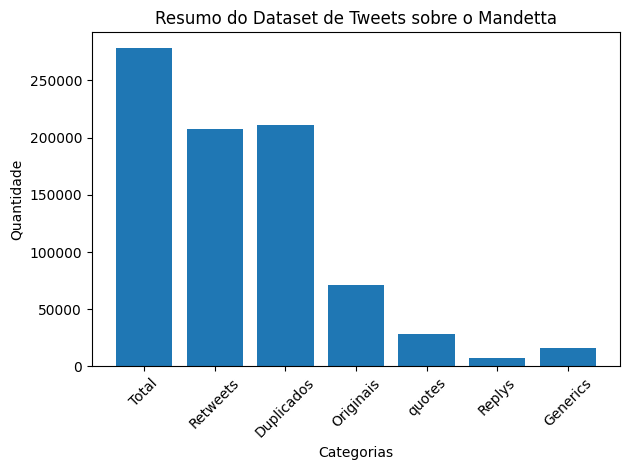

In [34]:
#Grafico resumindo:
total = num_tweets
retweets = num_rt
originais = num_tweets_or
duplicados_qtd = len(duplicados)
num_quotes = len(quotes)
num_replys = len(replys)
num_generics = len(generics)

labels = ["Total", "Retweets",  "Duplicados", "Originais", "quotes","Replys", "Generics"]
values = [total, retweets, duplicados_qtd, originais, num_quotes, num_replys, num_generics]

plt.figure()
plt.bar(labels, values)
plt.title("Resumo do Dataset de Tweets sobre o Mandetta")
plt.xlabel("Categorias")
plt.ylabel("Quantidade")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [35]:
#definindo classes de tweets - 0 Generics, 1 replys, 2 quotes

def classification (tweet_bas):
  #tweet generico (is_reply e is_quote = false)
    if (tweet_bas['is_reply'] == False) & (tweet_bas["is_quote"] == False):
      return 0
  #tweet reply (is_reply = True e is_quote = False)
    elif (tweet_bas['is_reply'] == True) & (tweet_bas["is_quote"] == False):
      return 1
  #Caso contrario é quote (sobreposição de reply e quote é quote, considerado aqui)
    else:
      return 2
df["class"] = df.apply(classification, axis = 1) #normalmente 'aply' opera numa coluna inteiro (axis = 0). Para pegar todas, axis = 1

In [36]:
df

,tweet_id,user_id_original,text,created_at_original,retweet_count,like_count,is_retweet,retweeter_user_id,retweet_created_at,is_quote,quoted_tweet_id,quoted_user_id,quoted_text,is_reply,reply_to_tweet_id,reply_to_user_id,reply_to_screen_name,reply_text,class
0,1263053750681382912,74756085,Sem distorções. JB brinca: tubaína ou cloroquina,Wed May 20 10:27:35 +0000 2020,2464,11709,True,1163629366875688961,Wed May 20 17:48:15 +0000 2020,False,None,None,,False,None,None,None,,0
1,1263164652806078466,64559578,Está se tornando uma irresponsabilidade a manu...,Wed May 20 17:48:16 +0000 2020,0,0,False,None,None,False,None,None,,False,None,None,None,,0
2,1263131993895841793,1087259768,Agora é oficial!!! Vamos de novo: Melhor ter u...,Wed May 20 15:38:29 +0000 2020,934,2934,True,1254218123995201536,Wed May 20 17:48:16 +0000 2020,True,1263130208967766024,128372940,O divulga orientações para tratamento da Covi...,False,None,None,None,,2
3,1263161628620701696,1262972424880041985,O publicou nesta manhã o novo protocolo do co...,Wed May 20 17:36:15 +0000 2020,22,61,True,26166110,Wed May 20 17:48:16 +0000 2020,False,None,None,,False,None,None,None,,0
4,1263154938672267267,1138847289978626049,O UOL fez uma matéria sobre o protocolo para c...,Wed May 20 17:09:40 +0000 2020,276,1196,True,1256311897852465152,Wed May 20 17:48:17 +0000 2020,False,None,None,,False,None,None,None,,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
278042,1263565981164716056,3105395998,"Entendo seu ponto, já li inúmeros estudos e pu...",Thu May 21 20:23:00 +0000 2020,0,0,False,None,None,False,None,None,,True,1263541899488636930,123527696,jaurojr,"Cara, deixa eu te explicar: não existem estudo...",1
278055,1263565990656426001,162110014,Quero ver quem me diz agora que isso não é lob...,Thu May 21 20:23:02 +0000 2020,0,0,False,None,None,True,1263498332590297090,70799317,"Militares já produziram 1,2 milhão de comprimi...",False,None,None,None,,2
278057,1263565991793090561,1251891753973690369,Acho bom e vc ficar quieto. Já já pegam seus p...,Thu May 21 20:23:03 +0000 2020,0,0,False,None,None,True,1263453648778153985,34996429,Apresentei um projeto de decreto legislativo p...,False,None,None,None,,2
278059,1263565993818894336,1208380137798017026,O MP tá dormindo ao invés de fazer algo para c...,Thu May 21 20:23:03 +0000 2020,0,0,False,None,None,True,1263558418159280130,1158389772920020993,O Brasil ganhou mais uma esperança no tratamen...,False,None,None,None,,2


In [37]:
df[df['tweet_id'].str.contains('1250533884296601603', na=False)]

,tweet_id,user_id_original,text,created_at_original,retweet_count,like_count,is_retweet,retweeter_user_id,retweet_created_at,is_quote,quoted_tweet_id,quoted_user_id,quoted_text,is_reply,reply_to_tweet_id,reply_to_user_id,reply_to_screen_name,reply_text,class


In [38]:
df[df['quoted_text'].str.contains('A maioria esmagadora dos brasileiros é contrária à demissão de Mandetta: 76,2% dos entrevistados discordam do afast', na=False)]

,tweet_id,user_id_original,text,created_at_original,retweet_count,like_count,is_retweet,retweeter_user_id,retweet_created_at,is_quote,quoted_tweet_id,quoted_user_id,quoted_text,is_reply,reply_to_tweet_id,reply_to_user_id,reply_to_screen_name,reply_text,class


In [41]:
#classe 0
sum_class_0 = int ((df['class'] == 0).sum())
sum_class_0


16360

In [42]:
#Classe 1
sum_class_1 = int ((df['class'] == 1).sum())
sum_class_1

22514

In [43]:
#classe 2
sum_class_2 = int ((df['class'] == 2).sum())
sum_class_2

28211

In [44]:
#convertendo para csv
df.to_csv("cloroquina.csv", index=False, encoding="utf-8")
files.download("cloroquina.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>